In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
path = '/content/fashion-mnist_train.csv'
df = pd.read_csv(path)

Mounted at /content/drive


In [2]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,2,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# ---------------------------------------------------------
# IMPORT REQUIRED LIBRARIES
# ---------------------------------------------------------

# tensorflow → used for loading dataset and deep learning
# matplotlib → used to display images and charts
# numpy → numerical operations

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------------------------
# LOAD FASHION MNIST DATASET
# ---------------------------------------------------------

# load_data() automatically downloads the dataset
# It splits into training and testing datasets

(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()


# ---------------------------------------------------------
# PRINT DATASET INFORMATION
# ---------------------------------------------------------

print("Number of training images:", train_images.shape[0])
print("Number of testing images:", test_images.shape[0])

print("Training image shape:", train_images.shape)
print("Testing image shape:", test_images.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of training images: 60000
Number of testing images: 10000
Training image shape: (60000, 28, 28)
Testing image shape: (10000, 28, 28)


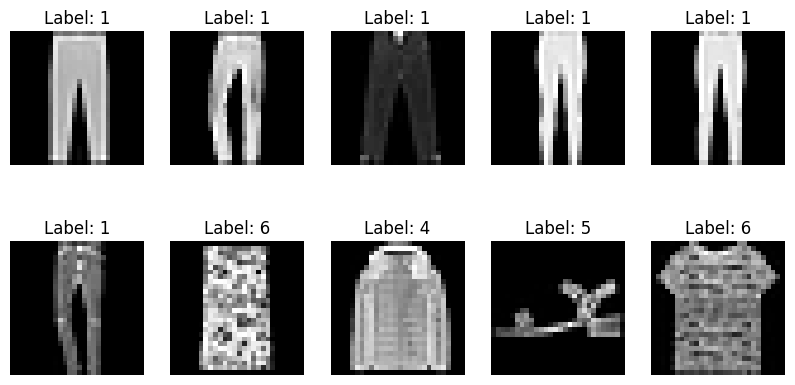

In [4]:
# ---------------------------------------------------------
# DISPLAY 10 RANDOM IMAGES
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

for i in range(10):

    # pick a random image index
    index = np.random.randint(0, len(train_images))

    plt.subplot(2,5,i+1)

    plt.imshow(train_images[index], cmap='gray')

    plt.title("Label: " + str(train_labels[index]))

    plt.axis('off')

plt.show()

In [5]:

train_images = train_images / 255.0
test_images = test_images / 255.0

In [6]:


train_images = train_images.reshape(-1,28,28,1)
test_images = test_images.reshape(-1,28,28,1)

print("New training shape:", train_images.shape)

New training shape: (60000, 28, 28, 1)


Images per class: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


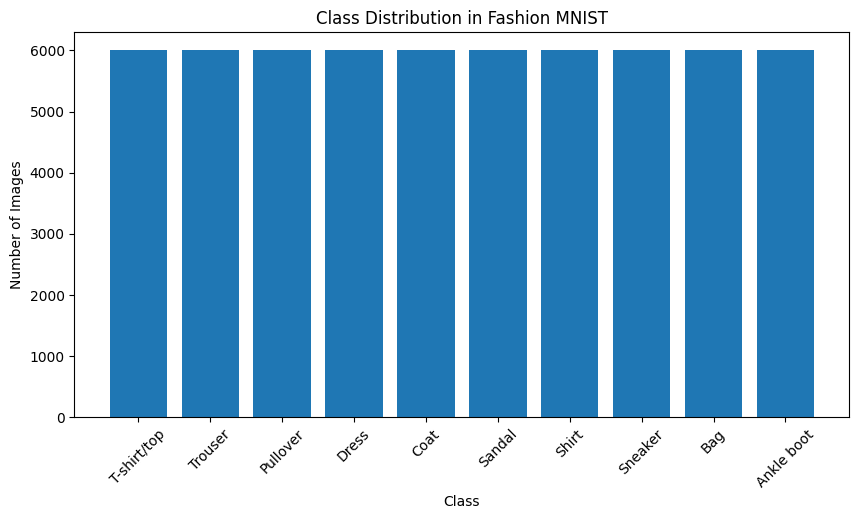

In [8]:

labels_numeric = train_labels

class_counts = np.bincount(labels_numeric)

print("Images per class:", class_counts)


# ---------------------------------------------------------
# PLOT BAR CHART
# ---------------------------------------------------------

classes = [
'T-shirt/top','Trouser','Pullover','Dress','Coat',
'Sandal','Shirt','Sneaker','Bag','Ankle boot'
]

plt.figure(figsize=(10,5))

plt.bar(classes, class_counts)

plt.xticks(rotation=45)

plt.title("Class Distribution in Fashion MNIST")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.show()

In [10]:
# ---------------------------------------------------------
# IMPORT LIBRARIES
# ---------------------------------------------------------

# tensorflow → deep learning framework
# keras → high-level API for neural networks

import tensorflow as tf
from tensorflow.keras import layers, models


# ---------------------------------------------------------
# BUILD CNN MODEL
# ---------------------------------------------------------

model = models.Sequential([

    # INPUT LAYER
    # Shape of Fashion-MNIST images
    layers.Input(shape=(28,28,1)),

    # ---------------------------------------------------------
    # FIRST CONVOLUTION LAYER
    # 32 filters detect edges, textures, simple patterns
    # kernel size = 3x3
    # activation = ReLU
    # ---------------------------------------------------------

    layers.Conv2D(32, (3,3), activation='relu'),

    # MAX POOLING reduces spatial size
    layers.MaxPooling2D((2,2)),

    # ---------------------------------------------------------
    # SECOND CONVOLUTION LAYER
    # Learns more complex patterns
    # ---------------------------------------------------------

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.MaxPooling2D((2,2)),

    # ---------------------------------------------------------
    # FLATTEN LAYER
    # Converts 2D feature maps → 1D vector
    # ---------------------------------------------------------

    layers.Flatten(),

    # ---------------------------------------------------------
    # FULLY CONNECTED LAYER
    # Learns complex relationships
    # ---------------------------------------------------------

    layers.Dense(128, activation='relu'),

    # OUTPUT LAYER
    # 10 neurons because dataset has 10 classes
    # softmax → probability distribution
    layers.Dense(10, activation='softmax')
])
model.compile(
    optimizer='adam',                     # optimization algorithm
    loss='categorical_crossentropy',      # multi-class classification loss
    metrics=['accuracy']                  # evaluation metric
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Convert labels to one-hot encoding
train_labels_one_hot = tf.keras.utils.to_categorical(train_labels, num_classes=10)
test_labels_one_hot = tf.keras.utils.to_categorical(test_labels, num_classes=10)

# Re-compile the model to ensure a fresh state for training
model.compile(
    optimizer='adam',                     # optimization algorithm
    loss='categorical_crossentropy',      # multi-class classification loss
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    train_labels_one_hot, # Use one-hot encoded labels
    epochs=10,
    batch_size=64,
    validation_data=(test_images, test_labels_one_hot) # Use one-hot encoded labels
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 55ms/step - accuracy: 0.7556 - loss: 0.6840 - val_accuracy: 0.8604 - val_loss: 0.3939
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.8834 - loss: 0.3250 - val_accuracy: 0.8848 - val_loss: 0.3277
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 56ms/step - accuracy: 0.8990 - loss: 0.2790 - val_accuracy: 0.8863 - val_loss: 0.3068
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 55ms/step - accuracy: 0.9099 - loss: 0.2443 - val_accuracy: 0.9034 - val_loss: 0.2676
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 54ms/step - accuracy: 0.9191 - loss: 0.2169 - val_accuracy: 0.9045 - val_loss: 0.2607
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9286 - loss: 0.1917 - val_accuracy: 0.9083 - val_loss: 0.2541
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 58ms/step - accuracy: 0.9344 - loss: 0.1763 - val_accuracy: 0.9136 - val_loss: 0.2405
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 77s 53ms/step - accuracy: 0.9422 - loss: 0.1526 - 

In [16]:
test_loss, test_acc = model.evaluate(test_images, test_labels_one_hot)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9098 - loss: 0.2774
Test Accuracy: 0.9126999974250793


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [19]:
# Get model predictions
predictions = model.predict(test_images)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Convert one-hot test labels back to numbers
true_labels = test_labels

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [20]:
cm = confusion_matrix(true_labels, predicted_labels)

print(cm)

[[870   0  11   7   5   2  98   0   7   0]
 [  3 984   0   4   4   0   3   0   2   0]
 [ 15   0 809  11  78   0  84   0   3   0]
 [ 14  13   5 909  26   0  30   0   3   0]
 [  0   0  19  29 892   0  60   0   0   0]
 [  0   0   0   0   0 973   0  17   0  10]
 [100   0  35  15  72   0 768   0  10   0]
 [  0   0   0   0   0   6   0 980   0  14]
 [  1   0   1   3   2   1   4   4 983   1]
 [  1   0   0   0   0   4   0  36   0 959]]


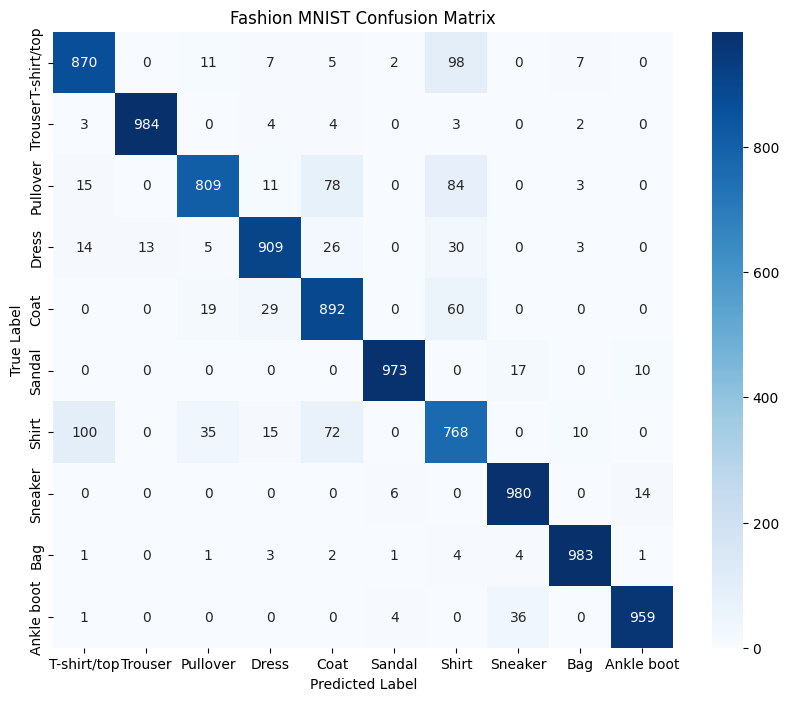

In [21]:
class_names = [
'T-shirt/top','Trouser','Pullover','Dress','Coat',
'Sandal','Shirt','Sneaker','Bag','Ankle boot'
]

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Fashion MNIST Confusion Matrix")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Total misclassified images: 873


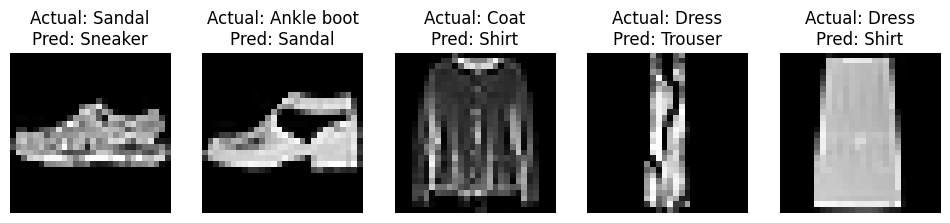


Explanation:
The CNN sometimes confuses visually similar classes.
For example:
• Shirt vs T-shirt
• Sneaker vs Ankle boot
• Coat vs Pullover
This happens because Fashion-MNIST images are small (28x28) and many clothing items have similar shapes.


In [23]:
# ---------------------------------------------------------
# TASK 10 — MISCLASSIFICATION ANALYSIS
# ---------------------------------------------------------

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

# Class labels for Fashion-MNIST
class_names = [
'T-shirt/top','Trouser','Pullover','Dress','Coat',
'Sandal','Shirt','Sneaker','Bag','Ankle boot'
]

# ---------------------------------------------------------
# STEP 1 — Get model predictions
# ---------------------------------------------------------

predictions = model.predict(test_images)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Convert one-hot encoded labels to numeric labels
true_labels = test_labels

# ---------------------------------------------------------
# STEP 2 — Find misclassified images
# ---------------------------------------------------------

misclassified_indices = []

for i in range(len(true_labels)):
    if predicted_labels[i] != true_labels[i]:
        misclassified_indices.append(i)

print("Total misclassified images:", len(misclassified_indices))

# ---------------------------------------------------------
# STEP 3 — Display 5 misclassified images
# ---------------------------------------------------------

plt.figure(figsize=(12,5))

for i in range(5):

    index = misclassified_indices[i]

    plt.subplot(1,5,i+1)

    # reshape image for display
    plt.imshow(test_images[index].reshape(28,28), cmap='gray')

    actual = class_names[true_labels[index]]
    predicted = class_names[predicted_labels[index]]

    plt.title(f"Actual: {actual}\nPred: {predicted}")

    plt.axis('off')

plt.show()

# ---------------------------------------------------------
# STEP 4 — Explanation
# ---------------------------------------------------------

print("\nExplanation:")
print("The CNN sometimes confuses visually similar classes.")
print("For example:")
print("• Shirt vs T-shirt")
print("• Sneaker vs Ankle boot")
print("• Coat vs Pullover")
print("This happens because Fashion-MNIST images are small (28x28) and many clothing items have similar shapes.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


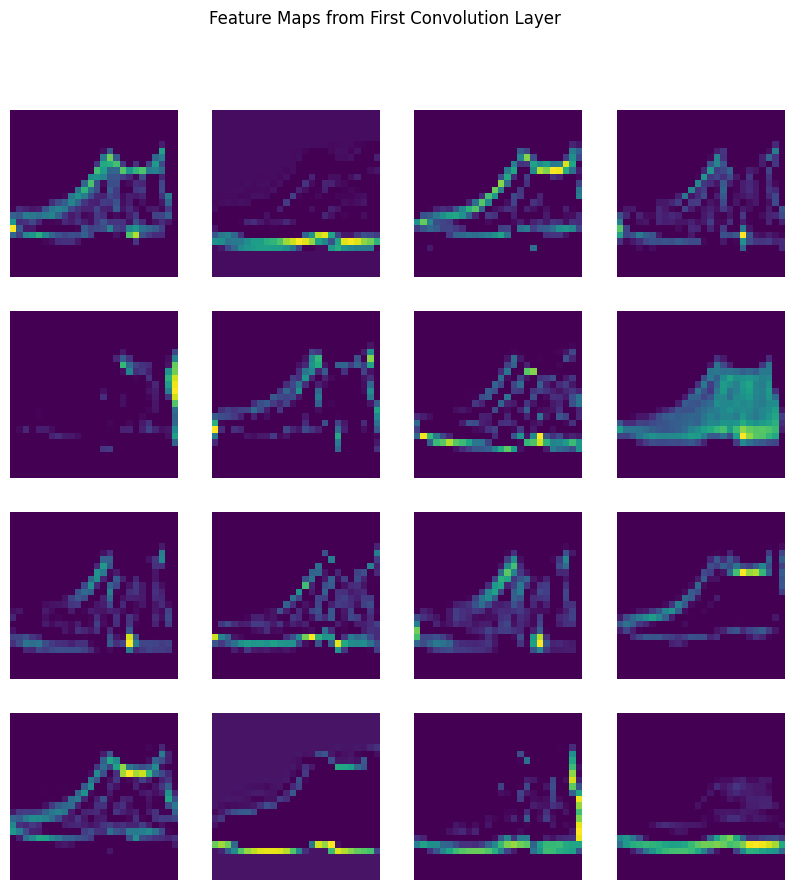

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


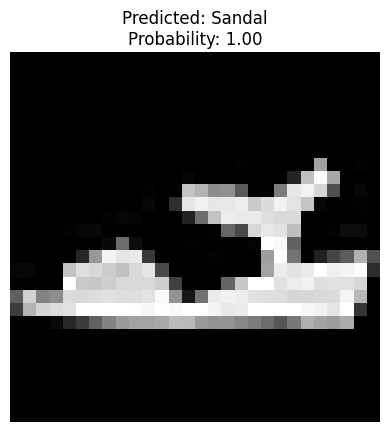

In [27]:
# ---------------------------------------------------------
# IMPORT LIBRARIES
# ---------------------------------------------------------

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


# Fashion-MNIST class names
class_names = [
'T-shirt/top','Trouser','Pullover','Dress','Coat',
'Sandal','Shirt','Sneaker','Bag','Ankle boot'
]


# ---------------------------------------------------------
# TASK 11 — FEATURE MAP VISUALIZATION
# ---------------------------------------------------------

# Select one test image
image = test_images[0]

# Expand dimension because model expects batch input
image_input = np.expand_dims(image, axis=0);

# Extract outputs of all layers
layer_outputs = [layer.output for layer in model.layers]

# Create feature extraction model by directly accessing the input of the first layer
feature_model = tf.keras.models.Model(inputs=model.layers[0].input, outputs=layer_outputs)

# Get feature maps
feature_maps = feature_model.predict(image_input)

# Display feature maps from first Conv layer
plt.figure(figsize=(10,10))

feature_map = feature_maps[0]   # first conv layer output

for i in range(16):  # display first 16 feature maps

    plt.subplot(4,4,i+1)

    plt.imshow(feature_map[0,:,:,i], cmap='viridis')

    plt.axis('off')

plt.suptitle("Feature Maps from First Convolution Layer")
plt.show()



# ---------------------------------------------------------
# TASK 12 — SIMPLE PREDICTION INTERFACE
# ---------------------------------------------------------

# Pick random test image
index = np.random.randint(0, len(test_images))

test_img = test_images[index]

# Predict class
prediction = model.predict(np.expand_dims(test_img, axis=0))

predicted_class = np.argmax(prediction)

probability = np.max(prediction)


# Display image and prediction
plt.imshow(test_img.reshape(28,28), cmap='gray')

plt.title(
    f"Predicted: {class_names[predicted_class]}\n"
    f"Probability: {probability:.2f}"
)

plt.axis('off')

plt.show()